# Loan Prediction using Machine Learning

## Objective
Predict whether a customer is eligible for a loan.

## Algorithms
- Logistic Regression
- Decision Tree

In [1]:
# ==========================================
# STEP 1 : Import Required Libraries
# ==========================================

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

In [2]:
# ==========================================
# STEP 2 : Load Dataset
# ==========================================

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [3]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


# ==========================================
# STEP 3 : Data Understanding
# ==========================================

In [4]:
train_df.shape

(593994, 13)

In [5]:
train_df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [7]:
train_df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [8]:
train_df.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [9]:
train_df.duplicated().sum()

np.int64(0)

In [10]:
# ==========================================
# STEP 4 : Data Cleaning
# ==========================================

In [11]:
# Check Missing Values
train_df.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [12]:
(train_df.isnull().sum()/len(train_df))*100

id                      0.0
annual_income           0.0
debt_to_income_ratio    0.0
credit_score            0.0
loan_amount             0.0
interest_rate           0.0
gender                  0.0
marital_status          0.0
education_level         0.0
employment_status       0.0
loan_purpose            0.0
grade_subgrade          0.0
loan_paid_back          0.0
dtype: float64

In [13]:
train_df = train_df.drop_duplicates()

In [14]:
train_df.duplicated().sum()

np.int64(0)

In [15]:
train_df.dtypes

id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                   object
marital_status           object
education_level          object
employment_status        object
loan_purpose             object
grade_subgrade           object
loan_paid_back          float64
dtype: object

In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [17]:
train_df.select_dtypes(include="object").columns

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

In [18]:
train_df["gender"].value_counts()

gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64

In [19]:
train_df["marital_status"].value_counts()

marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64

In [20]:
train_df["education_level"].value_counts()

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

In [21]:
train_df["employment_status"].value_counts()

employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64

In [22]:
for col in train_df.select_dtypes(include="object").columns:
    train_df[col] = train_df[col].str.strip()

In [23]:
train_df.head()


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


### Exploratory Data Analysis (EDA)

In [24]:
print("Rows and Columns :", train_df.shape)

Rows and Columns : (593994, 13)


In [25]:
numerical_columns = train_df.select_dtypes(include=["int64","float64"]).columns
categorical_columns = train_df.select_dtypes(include="object").columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'loan_paid_back'],
      dtype='object')

Categorical Columns
Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')


In [26]:
train_df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [27]:
train_df.columns.tolist()

['id',
 'annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade',
 'loan_paid_back']

In [28]:
# ==========================================
# Target Variable Analysis
# ==========================================

train_df["loan_paid_back"].value_counts()

loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

In [29]:
train_df["loan_paid_back"].value_counts(normalize=True) * 100

loan_paid_back
1.0    79.881952
0.0    20.118048
Name: proportion, dtype: float64

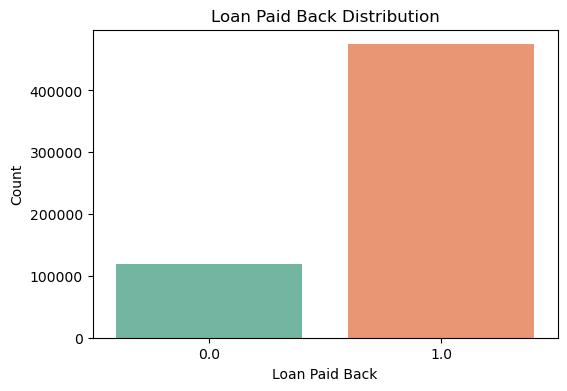

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="loan_paid_back",
    data=train_df,
    palette="Set2"
)

plt.title("Loan Paid Back Distribution")
plt.xlabel("Loan Paid Back")
plt.ylabel("Count")

plt.show()

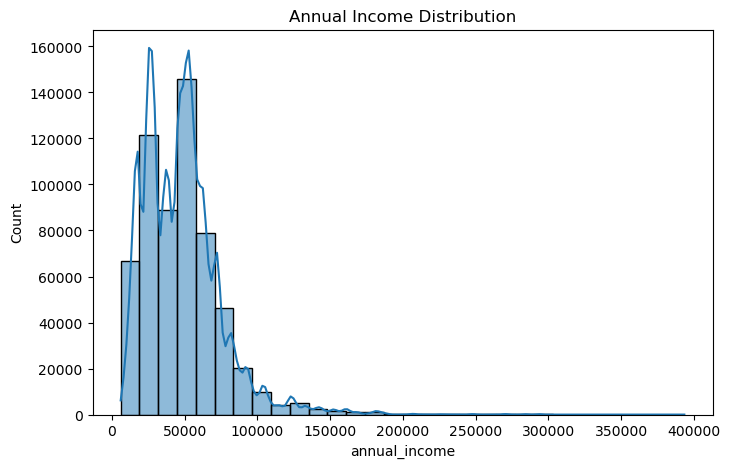

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["annual_income"], bins=30, kde=True)

plt.title("Annual Income Distribution")

plt.show()

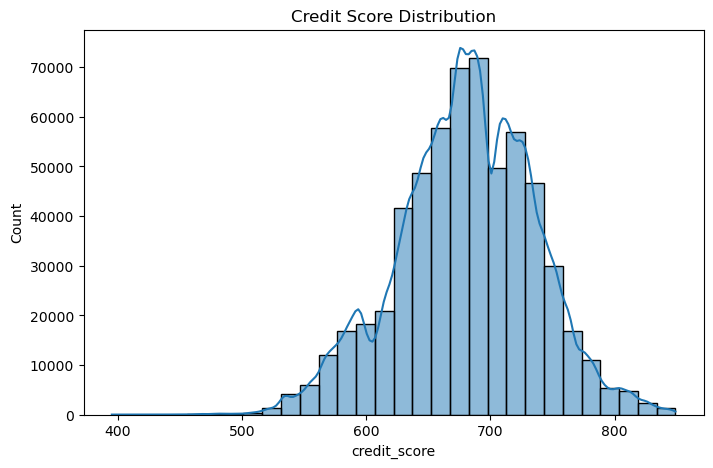

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["credit_score"], bins=30, kde=True)

plt.title("Credit Score Distribution")

plt.show()

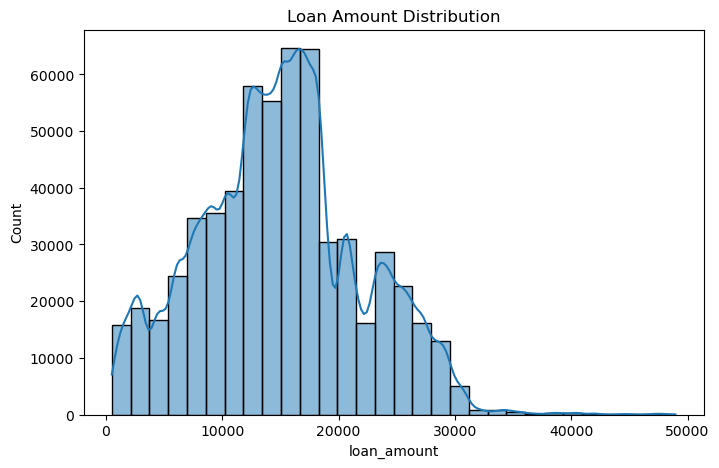

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["loan_amount"], bins=30, kde=True)

plt.title("Loan Amount Distribution")

plt.show()

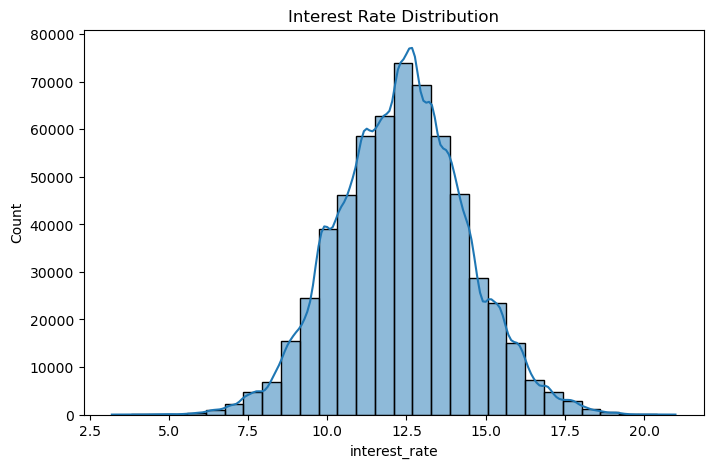

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["interest_rate"], bins=30, kde=True)

plt.title("Interest Rate Distribution")

plt.show()

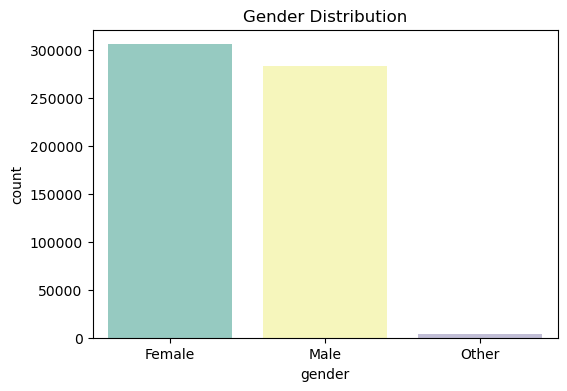

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    data=train_df,
    palette="Set3"
)

plt.title("Gender Distribution")

plt.show()

In [36]:
numeric_df = train_df.select_dtypes(include=["int64","float64"])

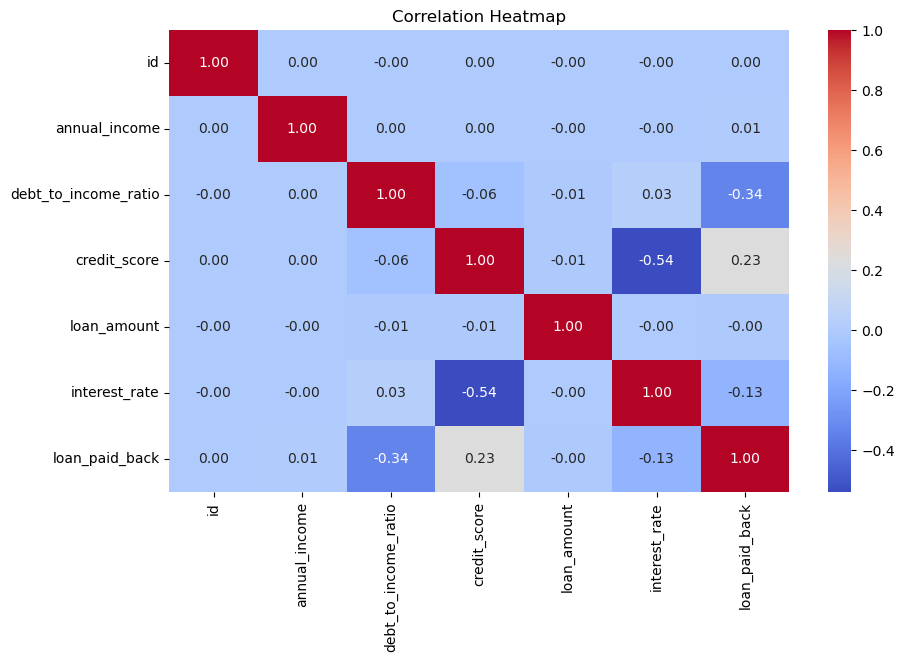

In [37]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [38]:
train_df["loan_paid_back"].value_counts()

loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

In [39]:
train_df["loan_paid_back"].value_counts(normalize=True) * 100

loan_paid_back
1.0    79.881952
0.0    20.118048
Name: proportion, dtype: float64

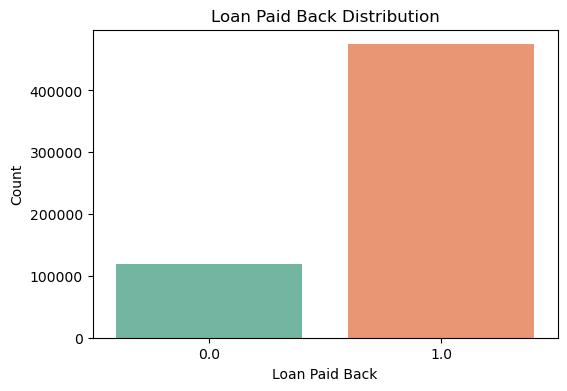

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(x="loan_paid_back", data=train_df, palette="Set2")

plt.title("Loan Paid Back Distribution")
plt.xlabel("Loan Paid Back")
plt.ylabel("Count")

plt.show()

In [41]:
numerical_columns = train_df.select_dtypes(include=["int64","float64"]).columns
print(numerical_columns)

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'loan_paid_back'],
      dtype='object')


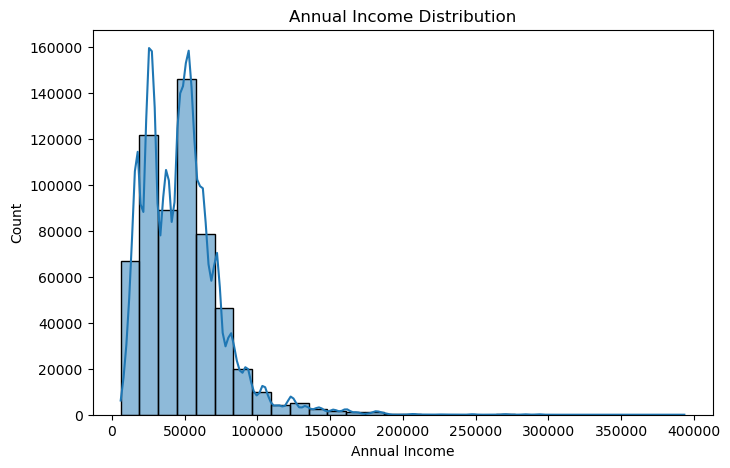

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["annual_income"], bins=30, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Count")

plt.show()

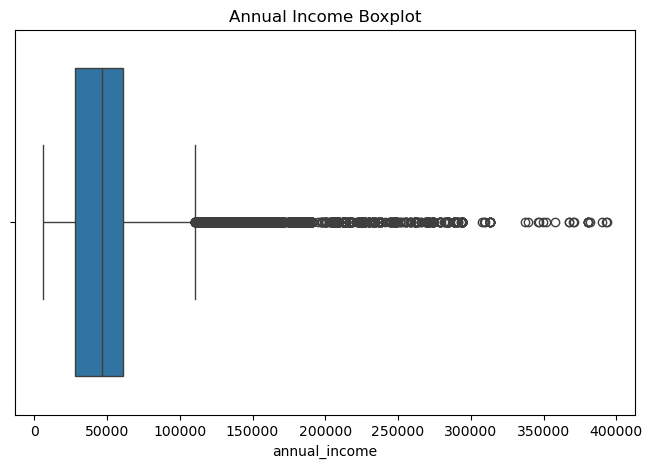

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_df["annual_income"])

plt.title("Annual Income Boxplot")

plt.show()

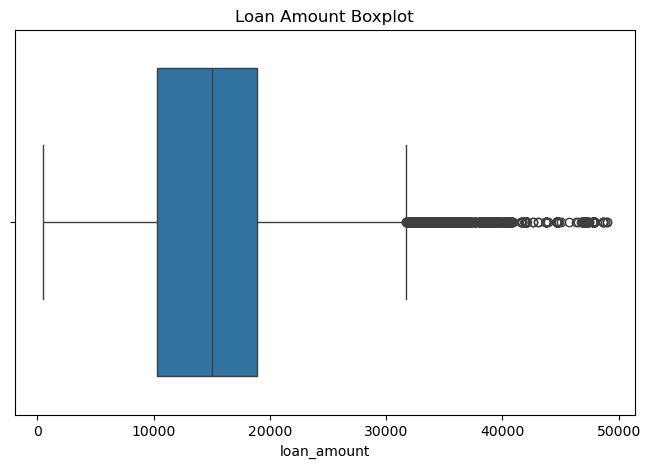

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_df["loan_amount"])

plt.title("Loan Amount Boxplot")

plt.show()

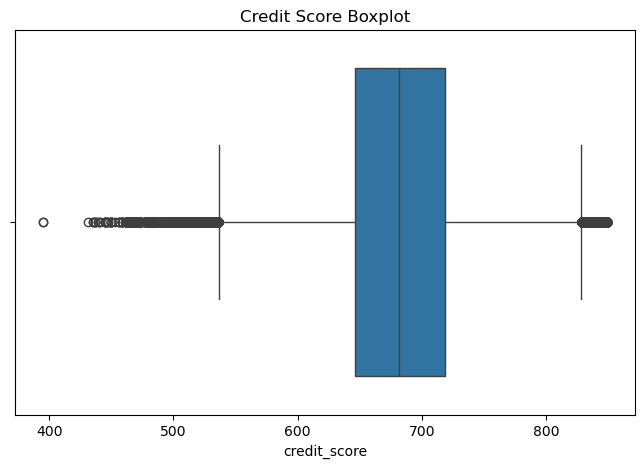

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_df["credit_score"])

plt.title("Credit Score Boxplot")

plt.show()

### Categorical Feature Analysis

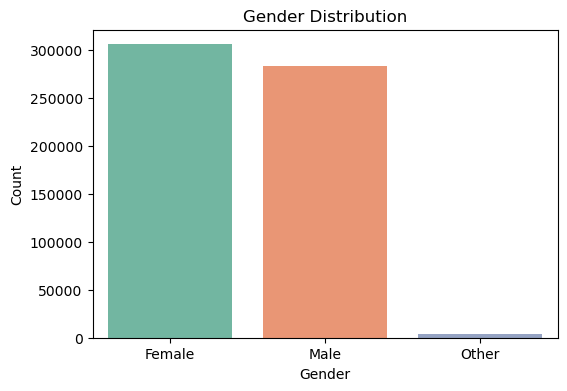

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", data=train_df, palette="Set2")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

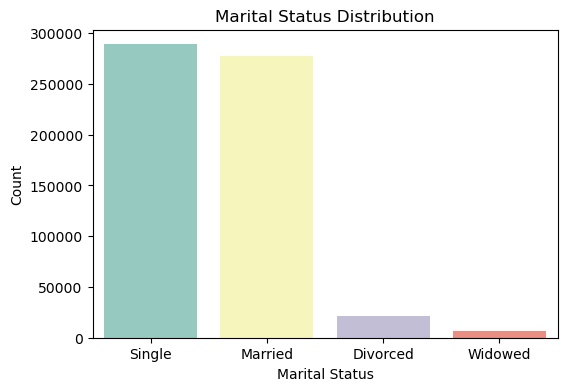

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(x="marital_status", data=train_df, palette="Set3")

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.show()

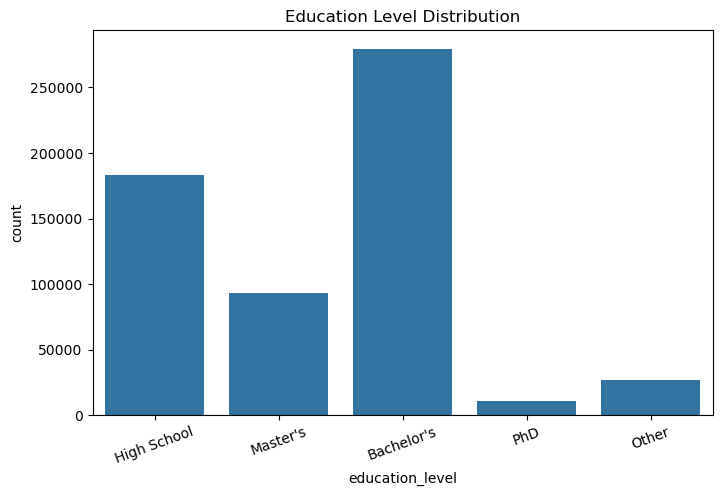

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(x="education_level", data=train_df)

plt.title("Education Level Distribution")
plt.xticks(rotation=20)

plt.show()

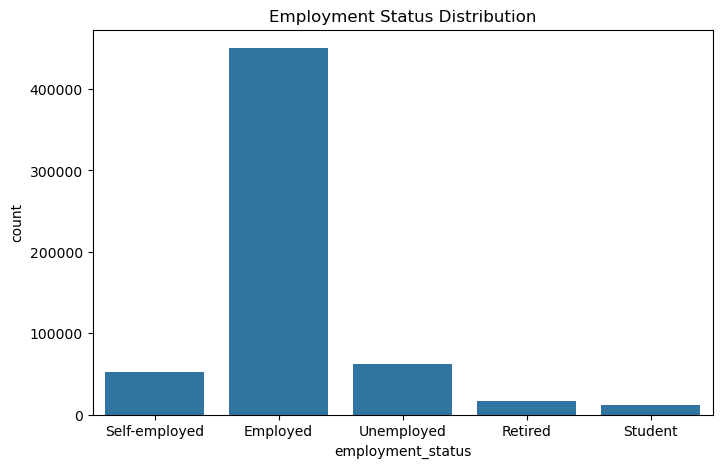

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(x="employment_status", data=train_df)

plt.title("Employment Status Distribution")

plt.show()

In [50]:
Q1 = train_df["credit_score"].quantile(0.25)
Q3 = train_df["credit_score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit :", lower)
print("Upper Limit :", upper)

Lower Limit : 536.5
Upper Limit : 828.5


In [51]:
outliers = train_df[
    (train_df["credit_score"] < lower) |
    (train_df["credit_score"] > upper)
]

print("Total Outliers :", len(outliers))

Total Outliers : 5901


In [52]:
train_df = train_df[
    (train_df["credit_score"] >= lower) &
    (train_df["credit_score"] <= upper)
]

### Feature Engineering & Data Preprocessing

In [53]:
# Create a copy of dataset

df = train_df.copy()

In [54]:
df.drop("id", axis=1, inplace=True)

In [55]:
df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
5,44940.30,0.058,653,12159.92,12.24,Male,Single,Bachelor's,Employed,Other,D1,1.0


In [56]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')


In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [58]:
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [59]:
df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,1.0
1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,0.0
2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,1.0
4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,1.0
5,44940.30,0.058,653,12159.92,12.24,1,2,0,0,6,15,1.0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 588093 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         588093 non-null  float64
 1   debt_to_income_ratio  588093 non-null  float64
 2   credit_score          588093 non-null  int64  
 3   loan_amount           588093 non-null  float64
 4   interest_rate         588093 non-null  float64
 5   gender                588093 non-null  int64  
 6   marital_status        588093 non-null  int64  
 7   education_level       588093 non-null  int64  
 8   employment_status     588093 non-null  int64  
 9   loan_purpose          588093 non-null  int64  
 10  grade_subgrade        588093 non-null  int64  
 11  loan_paid_back        588093 non-null  float64
dtypes: float64(5), int64(7)
memory usage: 58.3 MB


In [61]:
X = df.drop("loan_paid_back", axis=1)

y = df["loan_paid_back"]

In [62]:
print(X.shape)

print(y.shape)

(588093, 11)
(588093,)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [64]:
print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (470474, 11)
Testing Data : (117619, 11)


In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Model Building

In [66]:
# ==========================================
# Logistic Regression
# ==========================================

log_model = LogisticRegression(random_state=42)

In [67]:
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [68]:
y_pred_log = log_model.predict(X_test_scaled)

In [69]:
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy :", log_accuracy)

Logistic Regression Accuracy : 0.8925683775580476


In [70]:
cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[14093  9390]
 [ 3246 90890]]


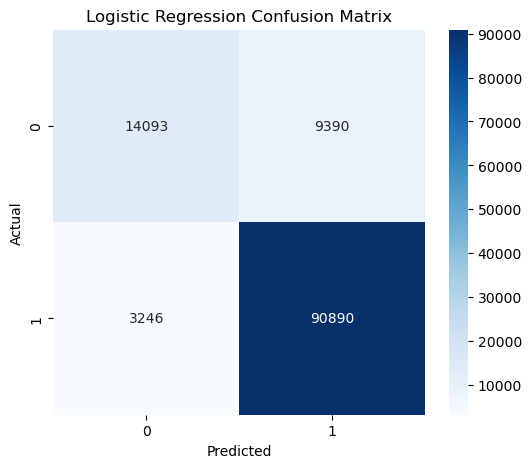

In [71]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [72]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

         0.0       0.81      0.60      0.69     23483
         1.0       0.91      0.97      0.94     94136

    accuracy                           0.89    117619
   macro avg       0.86      0.78      0.81    117619
weighted avg       0.89      0.89      0.89    117619



In [73]:
# ==========================================
# Decision Tree
# ==========================================

tree_model = DecisionTreeClassifier(
    random_state=42
)

In [74]:
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
y_pred_tree = tree_model.predict(X_test)

In [76]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy :", tree_accuracy)

Decision Tree Accuracy : 0.8471505454050791


In [77]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)

[[15121  8362]
 [ 9616 84520]]


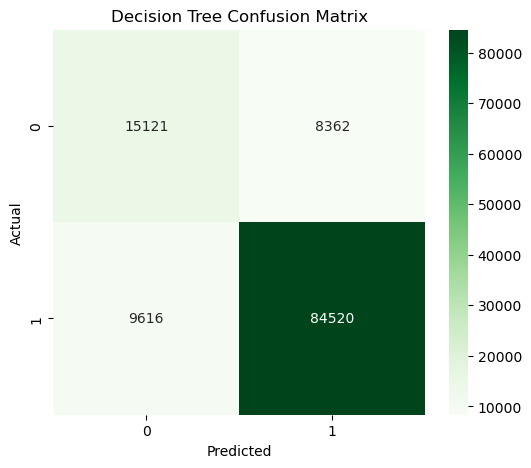

In [78]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [79]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

         0.0       0.61      0.64      0.63     23483
         1.0       0.91      0.90      0.90     94136

    accuracy                           0.85    117619
   macro avg       0.76      0.77      0.77    117619
weighted avg       0.85      0.85      0.85    117619



In [80]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        log_accuracy,
        tree_accuracy
    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.892568
1,Decision Tree,0.847151


In [81]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy               0.892568
Name: 0, dtype: object


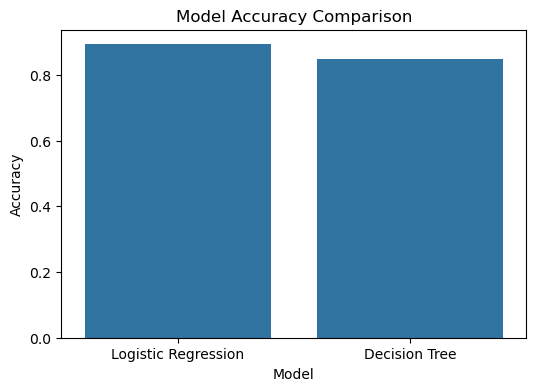

In [82]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

### Import Libraries

In [83]:
import joblib
import os

In [84]:
joblib.dump(log_model, "../saved_model/loan_model.pkl")

['../saved_model/loan_model.pkl']

In [85]:
joblib.dump(tree_model, "../saved_model/loan_model.pkl")

['../saved_model/loan_model.pkl']

In [86]:
joblib.dump(scaler, "../saved_model/scaler.pkl")

['../saved_model/scaler.pkl']

In [87]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    "gender",
    "marital_status",
    "education_level",
    "employment_status",
    "loan_purpose",
    "grade_subgrade"
]

for col in categorical_columns:
    le = LabelEncoder()
    le.fit(train_df[col])
    encoders[col] = le

In [88]:
joblib.dump(encoders, "../saved_model/encoders.pkl")

['../saved_model/encoders.pkl']

In [89]:
os.listdir("../saved_model")

['encoders.pkl', 'loan_model.pkl', 'scaler.pkl']

In [90]:
model = joblib.load("../saved_model/loan_model.pkl")

In [94]:
prediction = model.predict(X_test_scaled[:5])

print(prediction)

[0. 0. 1. 1. 1.]
